# Student Dropout Early-Warning System — Final NTI Notebook

## Project Goal

Build a university **early-warning decision-support system** that estimates the probability that a student will eventually drop out, explains the main drivers behind the prediction, assigns a **Low / Medium / High risk level**, and proposes advisor interventions.

The production prediction point in this notebook is **the end of Semester 1**. Therefore, Semester-2 variables are excluded from training to avoid future-data leakage.

The original target contains `Graduate`, `Dropout`, and `Enrolled`. `Enrolled` is an unresolved outcome, so the model is trained only on confirmed `Graduate` vs `Dropout` cases, then used to score currently enrolled students.


In [1]:
# Run once if needed
# !pip install -q xgboost shap joblib


In [2]:
import json
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

from sklearn.base import clone
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    roc_auc_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve
)

from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Dataset Source and What the Data Represents

**Dataset:** *Predict Students' Dropout and Academic Success*  
**Source:** UCI Machine Learning Repository  
**Creators:** Valentim Realinho, Mónica Vieira Martins, Jorge Machado, Luís Baptista  
**Year:** 2021  
**DOI:** `10.24432/C5MC89`

The dataset contains **4,424 students**, **36 input features**, and one target. It combines enrollment/prior-academic information, demographic and socioeconomic variables, first- and second-semester academic performance, and macroeconomic context.

### Important limitations before modeling

- The data does **not** contain attendance percentage, study hours, or assignment-completion percentage.
- `Daytime/evening attendance` means the student's **study schedule**, not attendance rate.
- The dataset comes from one higher-education institution, so a real deployment should retrain/validate on the target university's own data.
- Feature relationships are **associations**, not proof of causation.


In [3]:
feature_dictionary = pd.DataFrame([
    ["Marital status", "Categorical", "Student marital status.", "Codes 1–6", "May reflect different life responsibilities; non-actionable and not causal.", "Enrollment"],
    ["Application mode", "Categorical", "Admission pathway/mode used to enter the institution.", "Official admission-mode code", "Can capture different entry pathways, transfers, mature-entry routes, and prior education routes.", "Enrollment"],
    ["Application order", "Ordinal", "Position of this degree/program in the student's application preferences.", "0 = first choice; up to 9 = later choice", "Later preferences may correlate with program fit, but this is only an association.", "Enrollment"],
    ["Course", "Categorical", "Degree/program in which the student is enrolled.", "Official course code", "Programs can differ in workload, curriculum, selectivity, and historical retention patterns.", "Enrollment"],
    ["Daytime/evening attendance", "Binary", "Whether the student follows a daytime or evening schedule.", "1 = daytime; 0 = evening", "Schedule can relate to work/life constraints. This is NOT attendance percentage.", "Enrollment"],
    ["Previous qualification", "Categorical", "Qualification held before higher-education entry.", "Official education code", "Prior pathway can reflect preparation and transition into higher education.", "Enrollment"],
    ["Previous qualification (grade)", "Continuous", "Grade achieved in the previous qualification.", "0–200 scale", "Higher prior achievement may indicate stronger preparation.", "Enrollment"],
    ["Nacionality", "Categorical", "Student nationality; the source column is misspelled as 'Nacionality'.", "Official nationality code", "Sensitive/non-actionable background variable; fairness should be checked.", "Enrollment"],
    ["Mother's qualification", "Categorical", "Mother's education level.", "Official education code", "Family/socioeconomic-background proxy; non-actionable and not causal.", "Enrollment"],
    ["Father's qualification", "Categorical", "Father's education level.", "Official education code", "Family/socioeconomic-background proxy; non-actionable and not causal.", "Enrollment"],
    ["Mother's occupation", "Categorical", "Mother's occupation category.", "Official occupation code", "Socioeconomic-context proxy; non-actionable and should be interpreted cautiously.", "Enrollment"],
    ["Father's occupation", "Categorical", "Father's occupation category.", "Official occupation code", "Socioeconomic-context proxy; non-actionable and should be interpreted cautiously.", "Enrollment"],
    ["Admission grade", "Continuous", "Student admission grade.", "0–200 scale", "Direct indicator of academic preparation at entry.", "Enrollment"],
    ["Displaced", "Binary", "Whether the student is classified as displaced.", "1 = yes; 0 = no", "Relocation/living-context disruption may relate to support needs.", "Enrollment"],
    ["Educational special needs", "Binary", "Whether the student has special educational needs.", "1 = yes; 0 = no", "May indicate need for accessibility/support services; should never be framed as a deficit.", "Enrollment"],
    ["Debtor", "Binary", "Whether the student has debtor status.", "1 = yes; 0 = no", "May reflect financial/administrative pressure and is potentially actionable through support.", "Enrollment"],
    ["Tuition fees up to date", "Binary", "Whether tuition fees are up to date.", "1 = yes; 0 = no", "Financial/administrative status can be a warning signal and is actionable through support.", "Enrollment"],
    ["Gender", "Binary", "Student gender as encoded by the source.", "1 = male; 0 = female", "Sensitive/non-actionable; model behavior across groups should be audited.", "Enrollment"],
    ["Scholarship holder", "Binary", "Whether the student has a scholarship.", "1 = yes; 0 = no", "Can reflect access to financial support/resources.", "Enrollment"],
    ["Age at enrollment", "Integer", "Student age when enrolled.", "Years", "May correlate with work/family responsibilities and life stage; non-causal.", "Enrollment"],
    ["International", "Binary", "Whether the student is an international student.", "1 = yes; 0 = no", "Can relate to adjustment/support context; sensitive/non-actionable as a reason.", "Enrollment"],
    ["Curricular units 1st sem (credited)", "Integer", "Number of curricular units credited in Semester 1.", "Count", "Reflects recognized prior learning/credits and academic structure.", "Semester 1"],
    ["Curricular units 1st sem (enrolled)", "Integer", "Number of units enrolled in Semester 1.", "Count", "Represents academic load.", "Semester 1"],
    ["Curricular units 1st sem (evaluations)", "Integer", "Number of evaluations linked to Semester-1 curricular units.", "Count", "Reflects assessment activity and workload.", "Semester 1"],
    ["Curricular units 1st sem (approved)", "Integer", "Number of Semester-1 curricular units passed/approved.", "Count", "Direct measure of early academic progress; expected to be highly informative.", "Semester 1"],
    ["Curricular units 1st sem (grade)", "Continuous", "Average grade in Semester 1.", "0–20 scale", "Direct measure of early academic achievement.", "Semester 1"],
    ["Curricular units 1st sem (without evaluations)", "Integer", "Number of Semester-1 units without evaluation.", "Count", "Can indicate incomplete/missed assessment activity or unusual progression.", "Semester 1"],
    ["Curricular units 2nd sem (credited)", "Integer", "Number of curricular units credited in Semester 2.", "Count", "Potentially predictive but future information at our Semester-1 warning point; excluded.", "Future / excluded"],
    ["Curricular units 2nd sem (enrolled)", "Integer", "Number of units enrolled in Semester 2.", "Count", "Future information for the chosen early-warning point; excluded.", "Future / excluded"],
    ["Curricular units 2nd sem (evaluations)", "Integer", "Number of Semester-2 evaluations.", "Count", "Future information for the chosen early-warning point; excluded.", "Future / excluded"],
    ["Curricular units 2nd sem (approved)", "Integer", "Number of Semester-2 units passed/approved.", "Count", "Highly informative retrospectively, but too late for our Semester-1 intervention point; excluded.", "Future / excluded"],
    ["Curricular units 2nd sem (grade)", "Continuous", "Average grade in Semester 2.", "0–20 scale", "Highly informative but future information at the selected prediction point; excluded.", "Future / excluded"],
    ["Curricular units 2nd sem (without evaluations)", "Integer", "Number of Semester-2 units without evaluation.", "Count", "Future information for our operational prediction point; excluded.", "Future / excluded"],
    ["Unemployment rate", "Continuous", "Macroeconomic unemployment rate associated with the cohort.", "Percent", "Economic-context variable; not directly actionable by the university.", "Enrollment"],
    ["Inflation rate", "Continuous", "Macroeconomic inflation rate associated with the cohort.", "Percent", "Economic-context / possible financial-pressure proxy.", "Enrollment"],
    ["GDP", "Continuous", "GDP macroeconomic indicator supplied with the dataset.", "Unit not specified by source variable table", "Cohort-level economic context; not an individual cause.", "Enrollment"],
    ["Target", "Target", "Final status at the end of the normal duration of the course.", "Dropout / Enrolled / Graduate", "Prediction outcome. Enrolled is unresolved and not treated as a confirmed negative label.", "Outcome"]
], columns=[
    "Feature", "Type", "What it means", "Encoding / unit",
    "Why it may matter (not causal)", "Availability"
])

pd.set_option("display.max_colwidth", 120)
display(feature_dictionary)


,Feature,Type,What it means,Encoding / unit,Why it may matter (not causal),Availability
0,Marital status,Categorical,Student marital status.,Codes 1–6,May reflect different life responsibilities; non-actionable and not causal.,Enrollment
1,Application mode,Categorical,Admission pathway/mode used to enter the institution.,Official admission-mode code,"Can capture different entry pathways, transfers, mature-entry routes, and prior education routes.",Enrollment
2,Application order,Ordinal,Position of this degree/program in the student's application preferences.,0 = first choice; up to 9 = later choice,"Later preferences may correlate with program fit, but this is only an association.",Enrollment
3,Course,Categorical,Degree/program in which the student is enrolled.,Official course code,"Programs can differ in workload, curriculum, selectivity, and historical retention patterns.",Enrollment
4,Daytime/evening attendance,Binary,Whether the student follows a daytime or evening schedule.,1 = daytime; 0 = evening,Schedule can relate to work/life constraints. This is NOT attendance percentage.,Enrollment
5,Previous qualification,Categorical,Qualification held before higher-education entry.,Official education code,Prior pathway can reflect preparation and transition into higher education.,Enrollment
6,Previous qualification (grade),Continuous,Grade achieved in the previous qualification.,0–200 scale,Higher prior achievement may indicate stronger preparation.,Enrollment
7,Nacionality,Categorical,Student nationality; the source column is misspelled as 'Nacionality'.,Official nationality code,Sensitive/non-actionable background variable; fairness should be checked.,Enrollment
8,Mother's qualification,Categorical,Mother's education level.,Official education code,Family/socioeconomic-background proxy; non-actionable and not causal.,Enrollment
9,Father's qualification,Categorical,Father's education level.,Official education code,Family/socioeconomic-background proxy; non-actionable and not causal.,Enrollment


### Important Encoding Notes

Many columns are stored as integers but are actually **categories**, not numeric scales. Examples include `Course`, `Application mode`, `Previous qualification`, nationality, parents' qualifications, and parents' occupations.

A code of `122` for an occupation is not “larger” or “better” than code `9`; it is just a label. These features are therefore one-hot encoded in the model.


In [4]:
COURSE_MAP = {
    33: "Biofuel Production Technologies",
    171: "Animation and Multimedia Design",
    8014: "Social Service (evening)",
    9003: "Agronomy",
    9070: "Communication Design",
    9085: "Veterinary Nursing",
    9119: "Informatics Engineering",
    9130: "Equinculture",
    9147: "Management",
    9238: "Social Service",
    9254: "Tourism",
    9500: "Nursing",
    9556: "Oral Hygiene",
    9670: "Advertising and Marketing Management",
    9773: "Journalism and Communication",
    9853: "Basic Education",
    9991: "Management (evening)"
}

APPLICATION_MODE_MAP = {
    1: "1st phase - general contingent", 2: "Ordinance No. 612/93",
    5: "1st phase - special contingent (Azores)", 7: "Holders of other higher courses",
    10: "Ordinance No. 854-B/99", 15: "International student (bachelor)",
    16: "1st phase - special contingent (Madeira)", 17: "2nd phase - general contingent",
    18: "3rd phase - general contingent", 26: "Different Plan",
    27: "Other Institution", 39: "Over 23 years old", 42: "Transfer",
    43: "Change of course", 44: "Technological specialization diploma",
    51: "Change of institution/course", 53: "Short cycle diploma",
    57: "Change of institution/course (International)"
}

PREVIOUS_QUALIFICATION_MAP = {
    1: "Secondary education", 2: "Higher education - bachelor's degree",
    3: "Higher education - degree", 4: "Higher education - master's",
    5: "Higher education - doctorate", 6: "Frequency of higher education",
    9: "12th year not completed", 10: "11th year not completed",
    12: "Other - 11th year", 14: "10th year", 15: "10th year not completed",
    19: "Basic education 3rd cycle or equivalent",
    38: "Basic education 2nd cycle or equivalent",
    39: "Technological specialization course",
    40: "Higher education - degree (1st cycle)",
    42: "Professional higher technical course",
    43: "Higher education - master (2nd cycle)"
}

BINARY_MAPS = {
    "Daytime/evening attendance": {0: "Evening", 1: "Daytime"},
    "Displaced": {0: "No", 1: "Yes"},
    "Educational special needs": {0: "No", 1: "Yes"},
    "Debtor": {0: "No", 1: "Yes"},
    "Tuition fees up to date": {0: "No", 1: "Yes"},
    "Gender": {0: "Female", 1: "Male"},
    "Scholarship holder": {0: "No", 1: "Yes"},
    "International": {0: "No", 1: "Yes"}
}

print("Official course-code reference:")
display(pd.DataFrame(COURSE_MAP.items(), columns=["Code", "Course"]))


Official course-code reference:


,Code,Course
0,33,Biofuel Production Technologies
1,171,Animation and Multimedia Design
2,8014,Social Service (evening)
3,9003,Agronomy
4,9070,Communication Design
5,9085,Veterinary Nursing
6,9119,Informatics Engineering
7,9130,Equinculture
8,9147,Management
9,9238,Social Service


## 1. Load

In [5]:
from pathlib import Path

PROJECT_ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents)
                    if (path / "app.py").is_file() and (path / "models").is_dir())

df = pd.read_csv(PROJECT_ROOT / "data/raw/data.csv", sep=";")
df.columns = df.columns.str.strip()

print("Shape:", df.shape)
display(df.head())


Shape: (4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 2. Validate Data

In [6]:
print("Missing:", int(df.isna().sum().sum()))
print("Duplicates:", int(df.duplicated().sum()))

print("\nTarget:")
display(df["Target"].value_counts())


Missing: 0
Duplicates: 0

Target:


Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

## 3. Correct Target for Early-Warning

In [7]:
# Enrolled is not a confirmed final outcome.
# Train only on resolved outcomes: Dropout vs Graduate.
resolved = df[df["Target"].isin(["Dropout", "Graduate"])].copy()
unresolved = df[df["Target"] == "Enrolled"].copy()

resolved["Dropout"] = (resolved["Target"] == "Dropout").astype(int)

print("Resolved training rows:", len(resolved))
print("Unresolved Enrolled rows:", len(unresolved))
display(resolved["Target"].value_counts())


Resolved training rows: 3630
Unresolved Enrolled rows: 794


Target
Graduate    2209
Dropout     1421
Name: count, dtype: int64

## Exploratory Data Analysis and Observed Feature Effects

The following analysis uses only resolved outcomes (`Graduate` and `Dropout`) when calculating dropout rates. These are **descriptive associations**, not causal effects.


In [8]:
nominal_features_for_eda = {
    "Marital status", "Application mode", "Course", "Previous qualification",
    "Nacionality", "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation"
}

binary_features_for_eda = {
    "Daytime/evening attendance", "Displaced", "Educational special needs",
    "Debtor", "Tuition fees up to date", "Gender", "Scholarship holder", "International"
}

def readable_category(feature, value):
    if feature == "Course":
        return COURSE_MAP.get(value, str(value))
    if feature == "Application mode":
        return APPLICATION_MODE_MAP.get(value, str(value))
    if feature == "Previous qualification":
        return PREVIOUS_QUALIFICATION_MAP.get(value, str(value))
    if feature in BINARY_MAPS:
        return BINARY_MAPS[feature].get(value, str(value))
    return str(value)

association_rows = []

for col in [c for c in df.columns if c != "Target"]:
    if col in nominal_features_for_eda or col in binary_features_for_eda:
        grouped = (
            resolved.groupby(col)["Dropout"]
            .agg(["mean", "count"])
            .query("count >= 20")
            .sort_values("mean")
        )
        if len(grouped) >= 2:
            low_code, high_code = grouped.index[0], grouped.index[-1]
            association_rows.append({
                "Feature": col,
                "Analysis": "Categorical",
                "Observed relationship": (
                    f"Lowest dropout: {readable_category(col, low_code)} ({grouped.iloc[0]['mean']:.1%}); "
                    f"highest: {readable_category(col, high_code)} ({grouped.iloc[-1]['mean']:.1%})"
                ),
                "Association strength": grouped.iloc[-1]["mean"] - grouped.iloc[0]["mean"]
            })
        else:
            association_rows.append({
                "Feature": col,
                "Analysis": "Categorical",
                "Observed relationship": "Insufficient large subgroups for a stable comparison.",
                "Association strength": np.nan
            })
    else:
        grad_mean = resolved.loc[resolved["Dropout"] == 0, col].mean()
        drop_mean = resolved.loc[resolved["Dropout"] == 1, col].mean()
        corr = resolved[[col, "Dropout"]].corr(method="spearman").iloc[0, 1]
        direction = "higher among dropouts" if drop_mean > grad_mean else "lower among dropouts"
        association_rows.append({
            "Feature": col,
            "Analysis": "Numeric / ordinal",
            "Observed relationship": (
                f"Graduate mean={grad_mean:.2f}; Dropout mean={drop_mean:.2f} ({direction}); "
                f"Spearman r={corr:.3f}"
            ),
            "Association strength": abs(corr)
        })

association_table = pd.DataFrame(association_rows)
display(association_table)


,Feature,Analysis,Observed relationship,Association strength
0,Marital status,Categorical,Lowest dropout: 1 (37.0%); highest: 4 (56.0%),0.189884
1,Application mode,Categorical,Lowest dropout: Short cycle diploma (16.0%); highest: Over 23 years old (65.5%),0.495120
2,Application order,Numeric / ordinal,Graduate mean=1.85; Dropout mean=1.59 (lower among dropouts); Spearman r=-0.108,0.107600
3,Course,Categorical,Lowest dropout: Nursing (17.7%); highest: Informatics Engineering (86.8%),0.690747
4,Daytime/evening attendance,Categorical,Lowest dropout: Daytime (37.7%); highest: Evening (50.7%),0.130568
5,Previous qualification,Categorical,Lowest dropout: Professional higher technical course (21.4%); highest: Higher education - bachelor's degree (72.7%),0.512987
6,Previous qualification (grade),Numeric / ordinal,Graduate mean=134.08; Dropout mean=131.11 (lower among dropouts); Spearman r=-0.116,0.115847
7,Nacionality,Categorical,Lowest dropout: 1 (39.2%); highest: 41 (43.8%),0.045570
8,Mother's qualification,Categorical,Lowest dropout: 4 (23.5%); highest: 34 (75.6%),0.520611
9,Father's qualification,Categorical,Lowest dropout: 38 (29.0%); highest: 34 (74.3%),0.452684


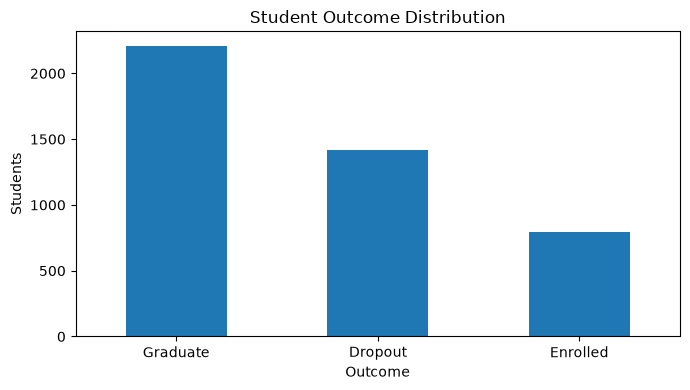

In [9]:
target_counts = df["Target"].value_counts()
plt.figure(figsize=(7, 4))
target_counts.plot(kind="bar")
plt.title("Student Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Students")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


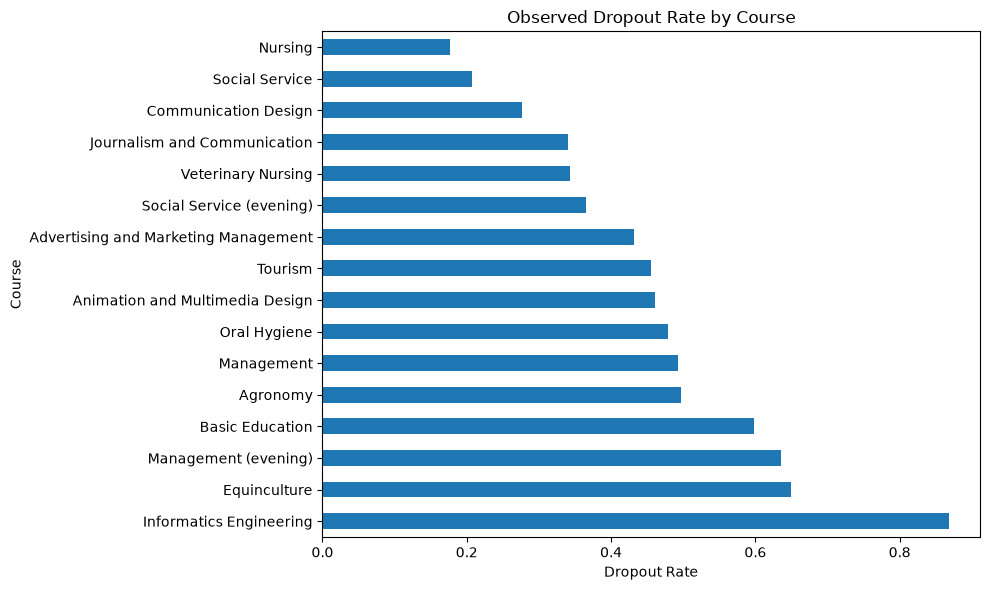

In [10]:
course_dropout = (
    resolved.assign(CourseName=resolved["Course"].map(COURSE_MAP))
    .groupby("CourseName")["Dropout"]
    .agg(["mean", "count"])
    .query("count >= 30")
    .sort_values("mean", ascending=False)
)
plt.figure(figsize=(10, 6))
course_dropout["mean"].plot(kind="barh")
plt.title("Observed Dropout Rate by Course")
plt.xlabel("Dropout Rate")
plt.ylabel("Course")
plt.tight_layout()
plt.show()


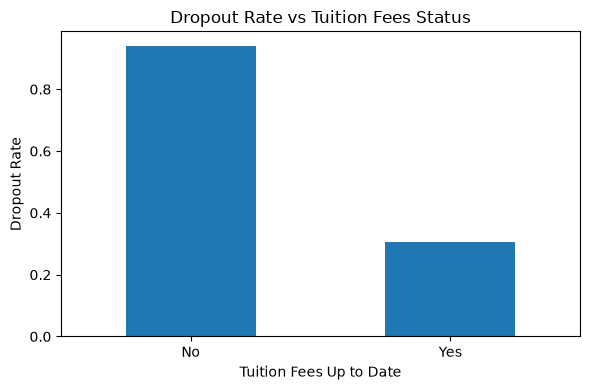

In [11]:
tuition_dropout = resolved.groupby("Tuition fees up to date")["Dropout"].mean().rename(index=BINARY_MAPS["Tuition fees up to date"])
plt.figure(figsize=(6, 4))
tuition_dropout.plot(kind="bar")
plt.title("Dropout Rate vs Tuition Fees Status")
plt.xlabel("Tuition Fees Up to Date")
plt.ylabel("Dropout Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


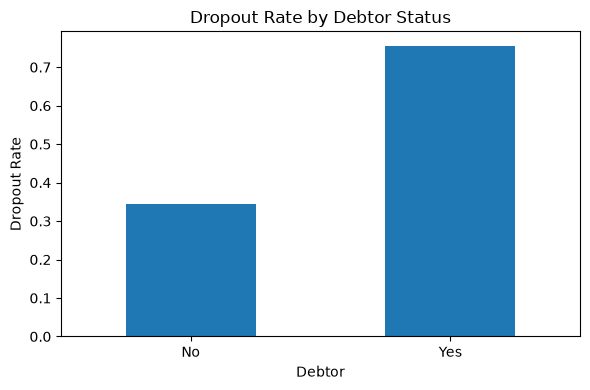

In [12]:
debtor_dropout = resolved.groupby("Debtor")["Dropout"].mean().rename(index=BINARY_MAPS["Debtor"])
plt.figure(figsize=(6, 4))
debtor_dropout.plot(kind="bar")
plt.title("Dropout Rate by Debtor Status")
plt.xlabel("Debtor")
plt.ylabel("Dropout Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


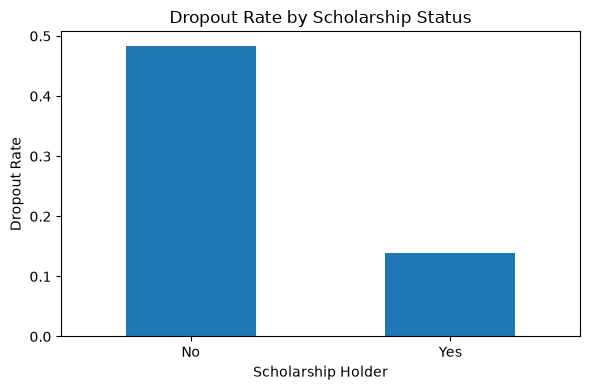

In [13]:
scholarship_dropout = resolved.groupby("Scholarship holder")["Dropout"].mean().rename(index=BINARY_MAPS["Scholarship holder"])
plt.figure(figsize=(6, 4))
scholarship_dropout.plot(kind="bar")
plt.title("Dropout Rate by Scholarship Status")
plt.xlabel("Scholarship Holder")
plt.ylabel("Dropout Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


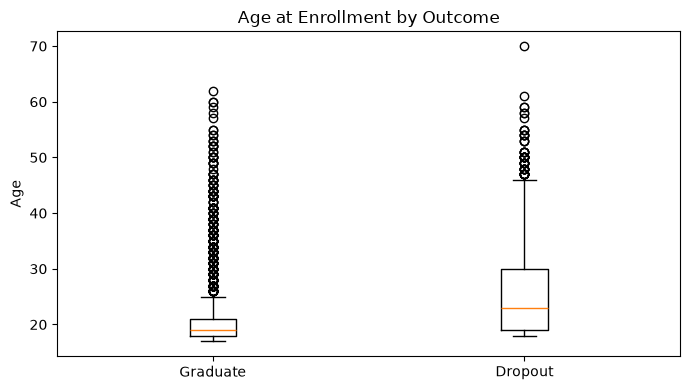

In [14]:
plt.figure(figsize=(7, 4))
plt.boxplot([
    resolved.loc[resolved["Target"] == "Graduate", "Age at enrollment"],
    resolved.loc[resolved["Target"] == "Dropout", "Age at enrollment"]
], tick_labels=["Graduate", "Dropout"])
plt.title("Age at Enrollment by Outcome")
plt.ylabel("Age")
plt.tight_layout()
plt.show()


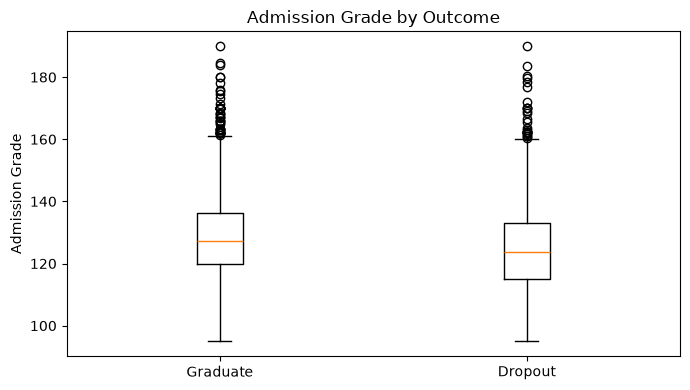

In [15]:
plt.figure(figsize=(7, 4))
plt.boxplot([
    resolved.loc[resolved["Target"] == "Graduate", "Admission grade"],
    resolved.loc[resolved["Target"] == "Dropout", "Admission grade"]
], tick_labels=["Graduate", "Dropout"])
plt.title("Admission Grade by Outcome")
plt.ylabel("Admission Grade")
plt.tight_layout()
plt.show()


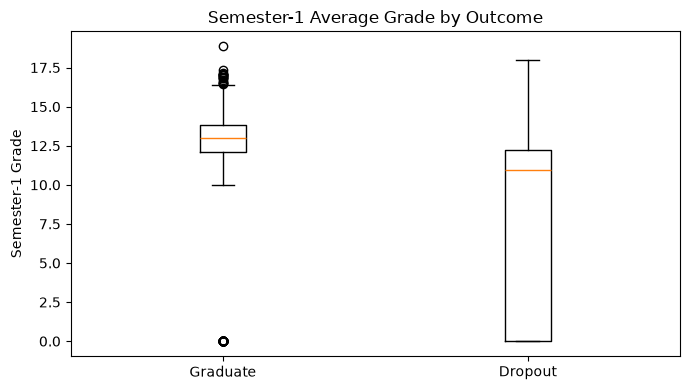

In [16]:
plt.figure(figsize=(7, 4))
plt.boxplot([
    resolved.loc[resolved["Target"] == "Graduate", "Curricular units 1st sem (grade)"],
    resolved.loc[resolved["Target"] == "Dropout", "Curricular units 1st sem (grade)"]
], tick_labels=["Graduate", "Dropout"])
plt.title("Semester-1 Average Grade by Outcome")
plt.ylabel("Semester-1 Grade")
plt.tight_layout()
plt.show()


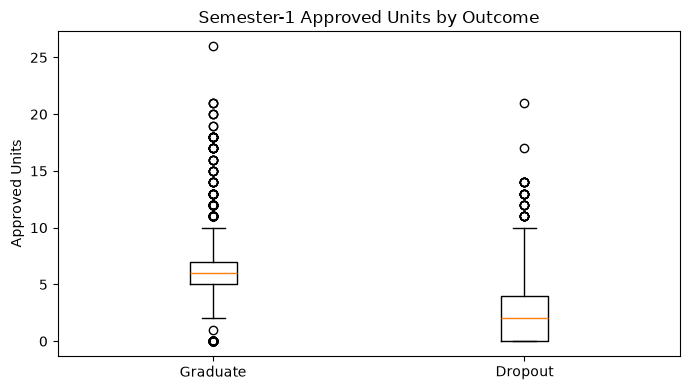

In [17]:
plt.figure(figsize=(7, 4))
plt.boxplot([
    resolved.loc[resolved["Target"] == "Graduate", "Curricular units 1st sem (approved)"],
    resolved.loc[resolved["Target"] == "Dropout", "Curricular units 1st sem (approved)"]
], tick_labels=["Graduate", "Dropout"])
plt.title("Semester-1 Approved Units by Outcome")
plt.ylabel("Approved Units")
plt.tight_layout()
plt.show()


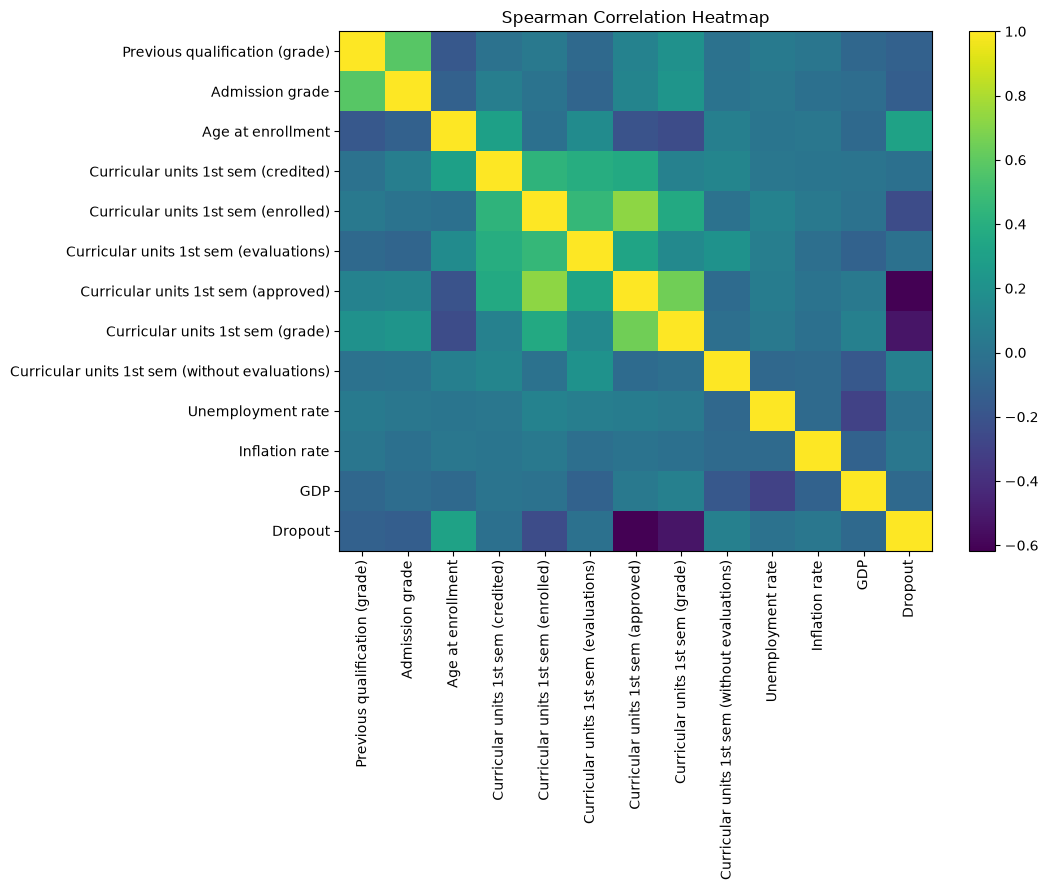

In [18]:
eda_numeric = [
    "Previous qualification (grade)", "Admission grade", "Age at enrollment",
    "Curricular units 1st sem (credited)", "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)", "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)", "Curricular units 1st sem (without evaluations)",
    "Unemployment rate", "Inflation rate", "GDP", "Dropout"
]
corr = resolved[eda_numeric].corr(method="spearman")
plt.figure(figsize=(11, 9))
image = plt.imshow(corr, aspect="auto")
plt.colorbar(image)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Spearman Correlation Heatmap")
plt.tight_layout()
plt.show()


## 4. Prevent Leakage

In [19]:
# Prediction point = end of Semester 1.
# Semester 2 features are future information, so remove them.
second_sem_cols = [
    c for c in resolved.columns
    if "2nd sem" in c
]

X = resolved.drop(
    columns=["Target", "Dropout"] + second_sem_cols
)
y = resolved["Dropout"]

print("Removed 2nd-semester columns:", len(second_sem_cols))
print("Features used:", X.shape[1])


Removed 2nd-semester columns: 6
Features used: 30


## 5. Feature Types

In [20]:
categorical_cols = [
    "Marital status",
    "Application mode",
    "Course",
    "Daytime/evening attendance",
    "Previous qualification",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "International"
]

categorical_cols = [
    c for c in categorical_cols
    if c in X.columns
]

numeric_cols = [
    c for c in X.columns
    if c not in categorical_cols
]

print("Numeric:", len(numeric_cols))
print("Categorical:", len(categorical_cols))


Numeric: 13
Categorical: 17


## 6. Untouched Test Set

In [21]:
X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

X_train, X_cal, y_train, y_cal = train_test_split(
    X_dev,
    y_dev,
    test_size=0.20,
    stratify=y_dev,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape)
print("Calibration:", X_cal.shape)
print("Test:", X_test.shape)


Train: (2323, 30)
Calibration: (581, 30)
Test: (726, 30)


## 7. Preprocessing

In [22]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])


## 8. Compare Models with 5-Fold CV

In [23]:
positive = int(y_train.sum())
negative = int((1 - y_train).sum())
scale_pos_weight = negative / positive

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=500,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=450,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=3,
        reg_lambda=2.0,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "PR_AUC": "average_precision",
    "ROC_AUC": "roc_auc",
    "Recall": "recall",
    "Precision": "precision",
    "F1": "f1"
}


In [24]:
cv_rows = []
pipelines = {}

for name, classifier in models.items():
    pipeline = Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("classifier", classifier)
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_rows.append({
        "Model": name,
        "CV PR-AUC": scores["test_PR_AUC"].mean(),
        "CV ROC-AUC": scores["test_ROC_AUC"].mean(),
        "CV Recall": scores["test_Recall"].mean(),
        "CV Precision": scores["test_Precision"].mean(),
        "CV F1": scores["test_F1"].mean()
    })

    pipelines[name] = pipeline

cv_results = pd.DataFrame(cv_rows).sort_values(
    "CV PR-AUC",
    ascending=False
).reset_index(drop=True)

display(cv_results)


,Model,CV PR-AUC,CV ROC-AUC,CV Recall,CV Precision,CV F1
0,XGBoost,0.927442,0.933293,0.825275,0.859159,0.841833
1,Logistic Regression,0.923770,0.930880,0.847253,0.851221,0.848959
2,Random Forest,0.918536,0.927837,0.801099,0.872412,0.835085
3,Extra Trees,0.896119,0.913506,0.765934,0.837977,0.800045


## 9. Select Best Model

In [25]:
best_model_name = cv_results.iloc[0]["Model"]
best_model = pipelines[best_model_name]

best_model.fit(X_train, y_train)

print("Selected:", best_model_name)


Selected: XGBoost


## 10. Probability Calibration

In [26]:
raw_cal_prob = best_model.predict_proba(X_cal)[:, 1]

calibrator = IsotonicRegression(
    out_of_bounds="clip"
)

calibrator.fit(
    raw_cal_prob,
    y_cal
)

cal_prob = calibrator.predict(raw_cal_prob)

print(
    "Calibration Brier Score:",
    round(brier_score_loss(y_cal, cal_prob), 4)
)


Calibration Brier Score: 0.0783


## 11. Tune Threshold

In [27]:
def choose_threshold_for_recall(
    y_true,
    probabilities,
    minimum_recall=0.85
):
    precision, recall, thresholds = precision_recall_curve(
        y_true,
        probabilities
    )

    candidates = []

    for i, threshold in enumerate(thresholds):
        if recall[i] >= minimum_recall:
            f1 = (
                2 * precision[i] * recall[i]
                / (precision[i] + recall[i] + 1e-12)
            )

            candidates.append({
                "threshold": float(threshold),
                "precision": float(precision[i]),
                "recall": float(recall[i]),
                "f1": float(f1)
            })

    if candidates:
        return max(
            candidates,
            key=lambda x: (x["precision"], x["f1"])
        )

    f1 = (
        2 * precision[:-1] * recall[:-1]
        / (precision[:-1] + recall[:-1] + 1e-12)
    )

    idx = int(np.argmax(f1))

    return {
        "threshold": float(thresholds[idx]),
        "precision": float(precision[idx]),
        "recall": float(recall[idx]),
        "f1": float(f1[idx])
    }


threshold_info = choose_threshold_for_recall(
    y_cal,
    cal_prob,
    minimum_recall=0.85
)

display(pd.DataFrame([threshold_info]))


,threshold,precision,recall,f1
0,0.473684,0.852174,0.863436,0.857768


## 12. Final Untouched Test

In [28]:
raw_test_prob = best_model.predict_proba(
    X_test
)[:, 1]

test_prob = calibrator.predict(
    raw_test_prob
)

threshold = threshold_info["threshold"]

test_pred = (
    test_prob >= threshold
).astype(int)

print(
    classification_report(
        y_test,
        test_pred,
        target_names=["Graduate", "Dropout"],
        digits=4
    )
)

test_metrics = {
    "Accuracy": accuracy_score(y_test, test_pred),
    "Precision": precision_score(y_test, test_pred),
    "Recall": recall_score(y_test, test_pred),
    "F1": f1_score(y_test, test_pred),
    "PR-AUC": average_precision_score(y_test, test_prob),
    "ROC-AUC": roc_auc_score(y_test, test_prob),
    "Brier Score": brier_score_loss(y_test, test_prob)
}

display(pd.DataFrame([test_metrics]))


              precision    recall  f1-score   support

    Graduate     0.9284    0.8801    0.9036       442
     Dropout     0.8274    0.8944    0.8596       284

    accuracy                         0.8857       726
   macro avg     0.8779    0.8872    0.8816       726
weighted avg     0.8889    0.8857    0.8864       726



,Accuracy,Precision,Recall,F1,PR-AUC,ROC-AUC,Brier Score
0,0.885675,0.827362,0.894366,0.85956,0.934398,0.951573,0.07929


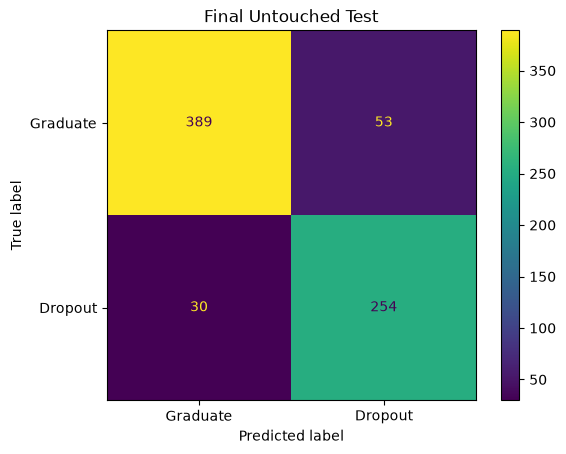

In [29]:
cm = confusion_matrix(
    y_test,
    test_pred
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Graduate", "Dropout"]
).plot()

plt.title("Final Untouched Test")
plt.show()


## Model Performance Visualizations

PR-AUC is especially important here because dropout is the minority class. Recall is also prioritized because an early-warning system should avoid missing students who are actually at risk.


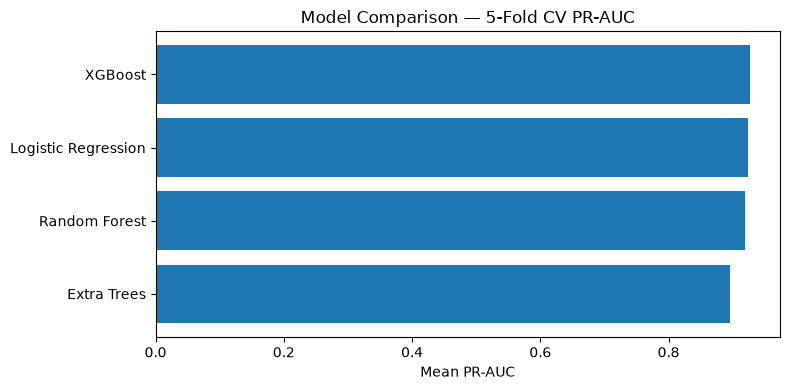

In [30]:
plot_df = cv_results.sort_values("CV PR-AUC")
plt.figure(figsize=(8, 4))
plt.barh(plot_df["Model"], plot_df["CV PR-AUC"])
plt.title("Model Comparison — 5-Fold CV PR-AUC")
plt.xlabel("Mean PR-AUC")
plt.tight_layout()
plt.show()


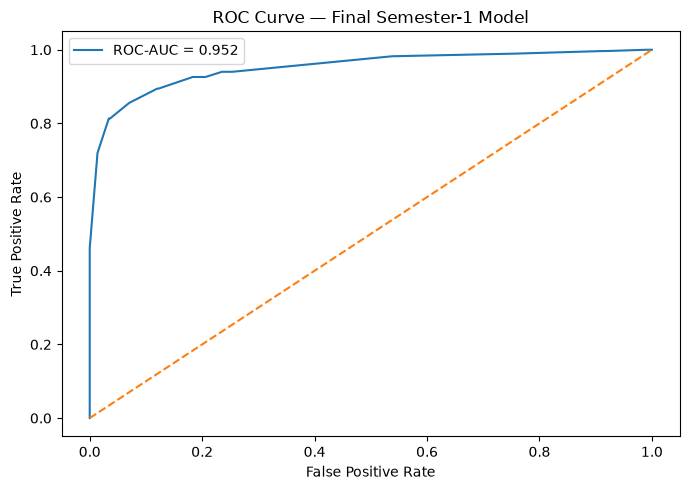

In [31]:
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, test_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test, test_prob):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve — Final Semester-1 Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()


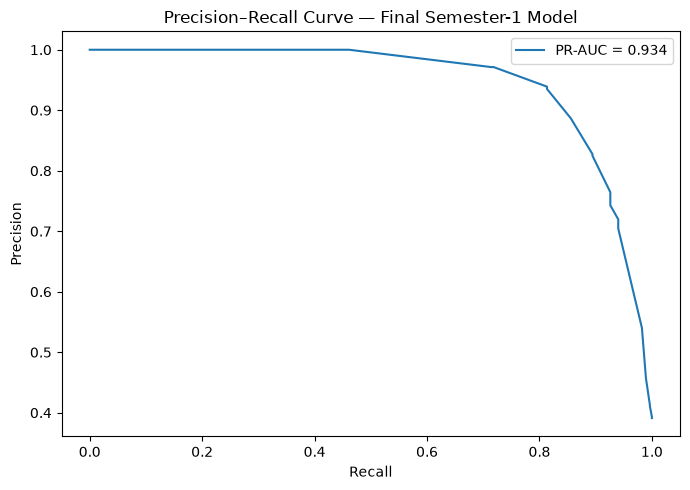

In [32]:
precision_curve, recall_curve, _ = precision_recall_curve(y_test, test_prob)
plt.figure(figsize=(7, 5))
plt.plot(recall_curve, precision_curve, label=f"PR-AUC = {average_precision_score(y_test, test_prob):.3f}")
plt.title("Precision–Recall Curve — Final Semester-1 Model")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()


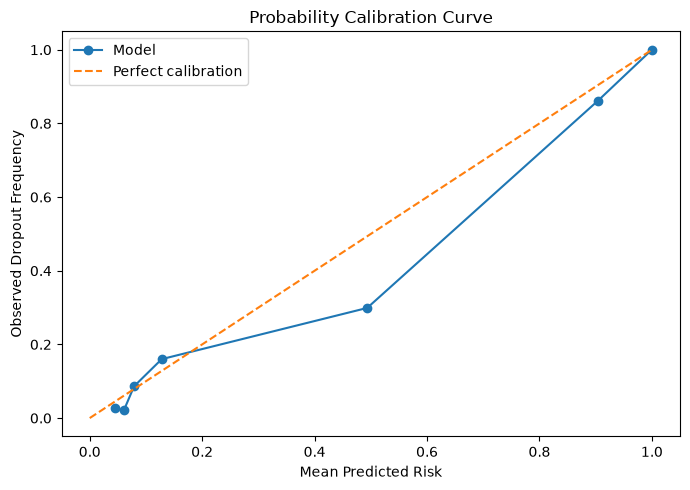

In [33]:
from sklearn.calibration import calibration_curve
frac_pos, mean_pred = calibration_curve(y_test, test_prob, n_bins=8, strategy="quantile")
plt.figure(figsize=(7, 5))
plt.plot(mean_pred, frac_pos, marker="o", label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.title("Probability Calibration Curve")
plt.xlabel("Mean Predicted Risk")
plt.ylabel("Observed Dropout Frequency")
plt.legend()
plt.tight_layout()
plt.show()


## 13. 95% Confidence Intervals

In [34]:
def bootstrap_metrics(
    y_true,
    probabilities,
    threshold,
    iterations=1000,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    y_array = np.asarray(y_true)
    p_array = np.asarray(probabilities)
    n = len(y_array)

    output = {
        "PR-AUC": [],
        "ROC-AUC": [],
        "Recall": [],
        "Precision": [],
        "F1": []
    }

    for _ in range(iterations):
        idx = rng.integers(0, n, n)

        y_sample = y_array[idx]
        p_sample = p_array[idx]

        if len(np.unique(y_sample)) < 2:
            continue

        pred_sample = (
            p_sample >= threshold
        ).astype(int)

        output["PR-AUC"].append(
            average_precision_score(
                y_sample,
                p_sample
            )
        )

        output["ROC-AUC"].append(
            roc_auc_score(
                y_sample,
                p_sample
            )
        )

        output["Recall"].append(
            recall_score(
                y_sample,
                pred_sample
            )
        )

        output["Precision"].append(
            precision_score(
                y_sample,
                pred_sample,
                zero_division=0
            )
        )

        output["F1"].append(
            f1_score(
                y_sample,
                pred_sample
            )
        )

    rows = []

    for metric, values in output.items():
        low, median, high = np.percentile(
            values,
            [2.5, 50, 97.5]
        )

        rows.append({
            "Metric": metric,
            "Estimate": median,
            "95% CI Low": low,
            "95% CI High": high
        })

    return pd.DataFrame(rows)


confidence_intervals = bootstrap_metrics(
    y_test,
    test_prob,
    threshold
)

display(confidence_intervals)


,Metric,Estimate,95% CI Low,95% CI High
0,PR-AUC,0.935159,0.911282,0.953138
1,ROC-AUC,0.952227,0.933846,0.967706
2,Recall,0.895270,0.855461,0.931038
3,Precision,0.828200,0.784565,0.868248
4,F1,0.860390,0.829861,0.889601


## 14. Feature Importance

In [35]:
importance = permutation_importance(
    best_model,
    X_cal,
    y_cal,
    scoring="average_precision",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "Feature": X_cal.columns,
    "Importance": importance.importances_mean
}).sort_values(
    "Importance",
    ascending=False
)

display(importance_df.head(15))


,Feature,Importance
24,Curricular units 1st sem (approved),0.309620
22,Curricular units 1st sem (enrolled),0.035198
16,Tuition fees up to date,0.031989
3,Course,0.015272
18,Scholarship holder,0.004815
25,Curricular units 1st sem (grade),0.004176
15,Debtor,0.003837
17,Gender,0.002041
29,GDP,0.001974
23,Curricular units 1st sem (evaluations),0.001499


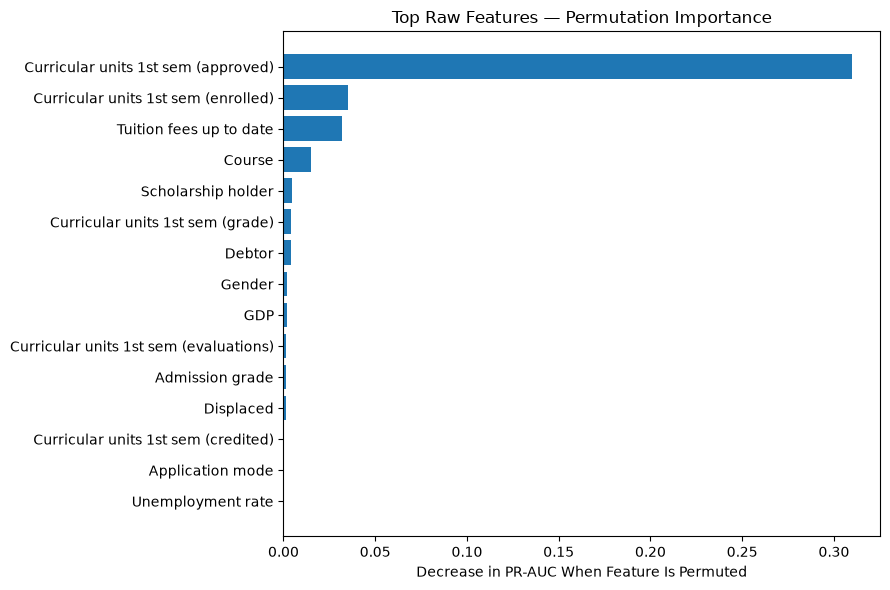

In [36]:
top_importance = importance_df.head(15).sort_values("Importance")
plt.figure(figsize=(9, 6))
plt.barh(top_importance["Feature"], top_importance["Importance"])
plt.title("Top Raw Features — Permutation Importance")
plt.xlabel("Decrease in PR-AUC When Feature Is Permuted")
plt.tight_layout()
plt.show()


## 15. Risk Score + Uncertainty

In [37]:
MEDIUM_RISK = 0.30
HIGH_RISK = threshold
REVIEW_MARGIN = 0.08

def predict_student_risk(student_df):
    raw_probability = best_model.predict_proba(
        student_df
    )[:, 1]

    probability = float(
        calibrator.predict(
            raw_probability
        )[0]
    )

    if probability >= HIGH_RISK:
        risk_level = "High"
    elif probability >= MEDIUM_RISK:
        risk_level = "Medium"
    else:
        risk_level = "Low"

    needs_review = (
        abs(probability - HIGH_RISK)
        <= REVIEW_MARGIN
    )

    return {
        "risk_score": round(
            probability * 100,
            2
        ),
        "risk_level": risk_level,
        "needs_human_review": needs_review
    }


In [38]:
sample_student = X_test.iloc[[0]]

display(sample_student)
print(
    predict_student_risk(
        sample_student
    )
)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Unemployment rate,Inflation rate,GDP
3622,1,1,2,9238,1,1,140.0,1,19,37,...,0,0,6,6,6,13.166667,0,10.8,1.4,1.74


{'risk_score': 5.36, 'risk_level': 'Low', 'needs_human_review': False}


## 16. Score Current Enrolled Students

In [39]:
unresolved_X = unresolved.drop(
    columns=["Target"] + second_sem_cols,
    errors="ignore"
)

unresolved_raw_prob = best_model.predict_proba(
    unresolved_X
)[:, 1]

unresolved_prob = calibrator.predict(
    unresolved_raw_prob
)

enrolled_scores = unresolved.copy()

enrolled_scores["Risk Score"] = np.round(
    unresolved_prob * 100,
    2
)

enrolled_scores["Risk Level"] = np.where(
    unresolved_prob >= HIGH_RISK,
    "High",
    np.where(
        unresolved_prob >= MEDIUM_RISK,
        "Medium",
        "Low"
    )
)

display(
    enrolled_scores[
        ["Risk Score", "Risk Level"]
    ].head(10)
)


,Risk Score,Risk Level
16,97.830002,High
19,47.369999,High
21,7.890000,Low
25,7.890000,Low
27,6.060000,Low
29,7.890000,Low
30,25.000000,Low
32,97.830002,High
45,97.830002,High
51,3.030000,Low


## Explainable AI, Current-Risk Visualization, Recommendations, and Fairness

The model should never output only “High Risk.” It should also show **why** and suggest an advisor action based on actionable signals. Sensitive attributes are not used to generate intervention recommendations.


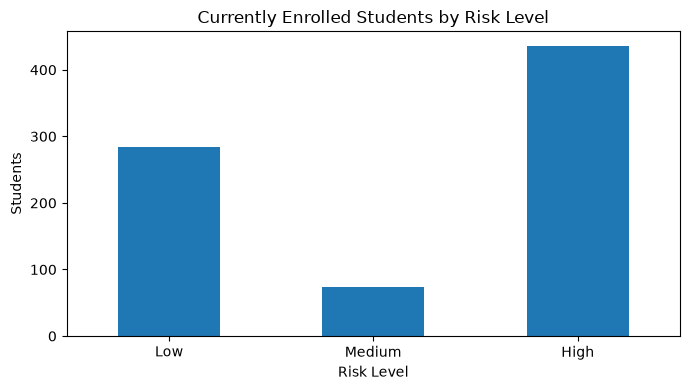

,Students
Risk Level,
Low,284
Medium,74
High,436


In [40]:
risk_counts = enrolled_scores["Risk Level"].value_counts().reindex(["Low", "Medium", "High"], fill_value=0)
plt.figure(figsize=(7, 4))
risk_counts.plot(kind="bar")
plt.title("Currently Enrolled Students by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Students")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
display(risk_counts.to_frame("Students"))


In [41]:
import shap

def transformed_to_raw_feature(transformed_name, numeric_cols, categorical_cols):
    if transformed_name.startswith("num__"):
        return transformed_name.replace("num__", "", 1)
    if transformed_name.startswith("cat__"):
        remainder = transformed_name.replace("cat__", "", 1)
        for col in sorted(categorical_cols, key=len, reverse=True):
            if remainder.startswith(col + "_"):
                return col
    return transformed_name

pre = best_model.named_steps["preprocessor"]
clf = best_model.named_steps["classifier"]
transformed_names = pre.get_feature_names_out()
raw_feature_names = [
    transformed_to_raw_feature(name, numeric_cols, categorical_cols)
    for name in transformed_names
]

shap_global = pd.DataFrame()
local_explanation = pd.DataFrame()

if isinstance(clf, XGBClassifier):
    shap_sample = X_test.sample(n=min(300, len(X_test)), random_state=RANDOM_STATE)
    X_shap = pre.transform(shap_sample)
    explainer = shap.TreeExplainer(clf)
    shap_values = explainer.shap_values(X_shap)

    shap_global = pd.DataFrame({
        "Raw Feature": raw_feature_names,
        "Mean |SHAP|": np.abs(shap_values).mean(axis=0)
    }).groupby("Raw Feature", as_index=False)["Mean |SHAP|"].sum()\
      .sort_values("Mean |SHAP|", ascending=False)\
      .reset_index(drop=True)

    display(shap_global)
else:
    print("Selected model is not XGBoost; permutation importance remains the global explanation.")


,Raw Feature,Mean |SHAP|
0,Curricular units 1st sem (approved),1.665244
1,Tuition fees up to date,0.444410
2,Course,0.403470
3,Curricular units 1st sem (grade),0.376507
4,Curricular units 1st sem (enrolled),0.353538
5,Scholarship holder,0.304059
6,Age at enrollment,0.250394
7,Admission grade,0.209767
8,Unemployment rate,0.207061
9,Gender,0.202422


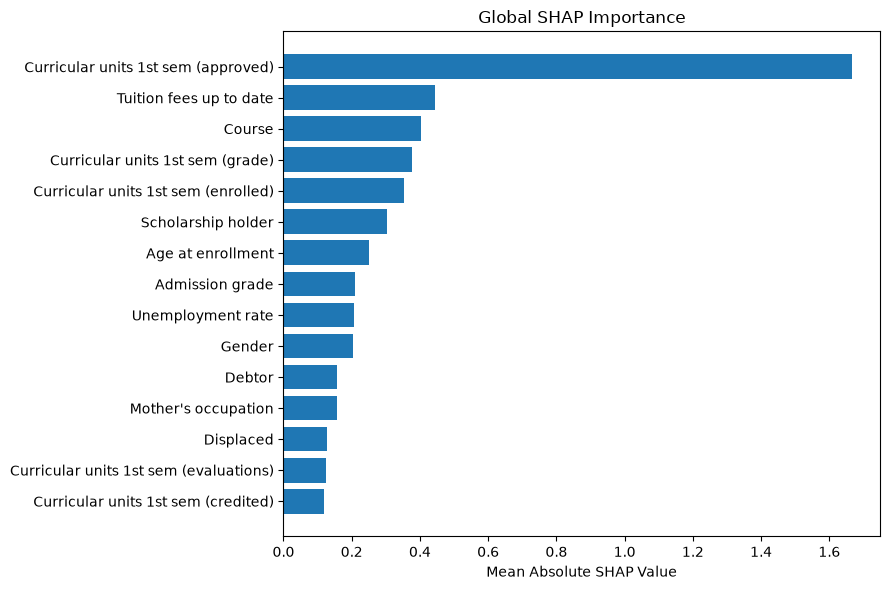

In [42]:
if not shap_global.empty:
    shap_top = shap_global.head(15).sort_values("Mean |SHAP|")
    plt.figure(figsize=(9, 6))
    plt.barh(shap_top["Raw Feature"], shap_top["Mean |SHAP|"])
    plt.title("Global SHAP Importance")
    plt.xlabel("Mean Absolute SHAP Value")
    plt.tight_layout()
    plt.show()


In [43]:
highest_risk_index = enrolled_scores["Risk Score"].idxmax()
highest_risk_student = unresolved_X.loc[[highest_risk_index]]
print("Highest-risk currently enrolled row:", highest_risk_index)
print("Risk score:", f"{enrolled_scores.loc[highest_risk_index, 'Risk Score']:.2f}%")
display(highest_risk_student)

if isinstance(clf, XGBClassifier):
    transformed_student = pre.transform(highest_risk_student)
    local_shap = explainer.shap_values(transformed_student)[0]
    local_detail = pd.DataFrame({"Raw Feature": raw_feature_names, "SHAP": local_shap})
    local_explanation = local_detail.groupby("Raw Feature", as_index=False)["SHAP"].sum()
    local_explanation["Absolute Impact"] = local_explanation["SHAP"].abs()
    local_explanation["Direction"] = np.where(
        local_explanation["SHAP"] > 0,
        "Pushes risk toward Dropout",
        "Pushes risk toward Graduate"
    )
    local_explanation = local_explanation.sort_values("Absolute Impact", ascending=False).reset_index(drop=True)
    display(local_explanation.head(12))


Highest-risk currently enrolled row: 64
Risk score: 100.00%


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Unemployment rate,Inflation rate,GDP
64,1,43,1,9070,1,1,116.0,1,1,1,...,0,0,6,6,0,0.0,0,12.7,3.7,-1.7


,Raw Feature,SHAP,Absolute Impact,Direction
0,Curricular units 1st sem (approved),3.171127,3.171127,Pushes risk toward Dropout
1,Curricular units 1st sem (grade),0.757480,0.757480,Pushes risk toward Dropout
2,Curricular units 1st sem (enrolled),0.465277,0.465277,Pushes risk toward Dropout
3,Mother's occupation,-0.289463,0.289463,Pushes risk toward Graduate
4,Gender,0.256951,0.256951,Pushes risk toward Dropout
5,Age at enrollment,0.214075,0.214075,Pushes risk toward Dropout
6,Scholarship holder,0.205968,0.205968,Pushes risk toward Dropout
7,Previous qualification (grade),0.178306,0.178306,Pushes risk toward Dropout
8,Unemployment rate,0.168978,0.168978,Pushes risk toward Dropout
9,Tuition fees up to date,-0.161861,0.161861,Pushes risk toward Graduate


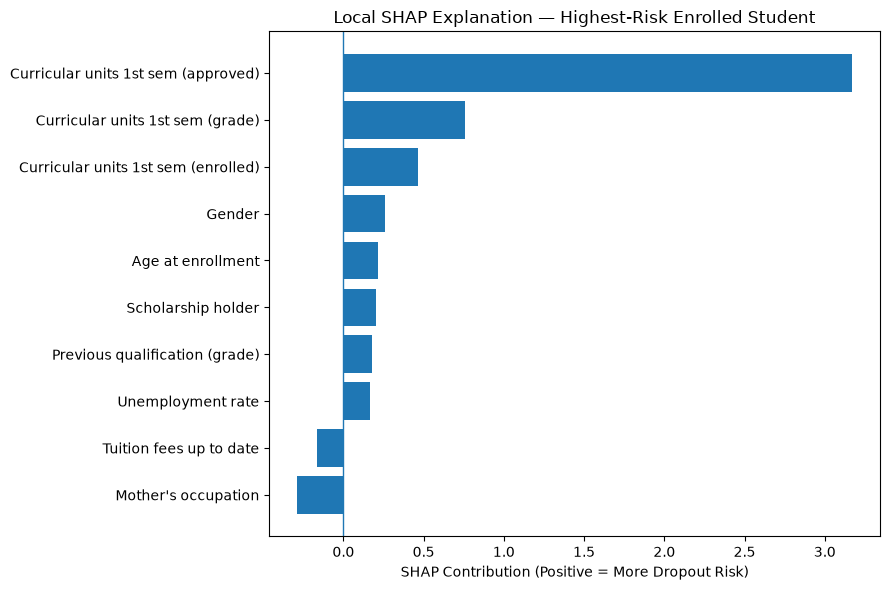

In [44]:
if not local_explanation.empty:
    local_plot = local_explanation.head(10).sort_values("SHAP")
    plt.figure(figsize=(9, 6))
    plt.barh(local_plot["Raw Feature"], local_plot["SHAP"])
    plt.axvline(0, linewidth=1)
    plt.title("Local SHAP Explanation — Highest-Risk Enrolled Student")
    plt.xlabel("SHAP Contribution (Positive = More Dropout Risk)")
    plt.tight_layout()
    plt.show()


### Advisor Recommendation Engine

Recommendations deliberately use **actionable academic/financial signals** rather than gender, nationality, age, or family background.


In [45]:
def advisor_recommendations(student_row):
    recommendations = []
    enrolled_units = student_row["Curricular units 1st sem (enrolled)"]
    approved_units = student_row["Curricular units 1st sem (approved)"]
    grade = student_row["Curricular units 1st sem (grade)"]
    no_eval = student_row["Curricular units 1st sem (without evaluations)"]
    pass_rate = approved_units / enrolled_units if enrolled_units > 0 else 0

    if pass_rate < 0.50:
        recommendations.append("Urgent academic-advisor meeting and targeted tutoring because fewer than half of Semester-1 units were approved.")
    if grade < 10:
        recommendations.append("Create an academic support/study plan and connect the student with tutoring because the Semester-1 average grade is below 10/20.")
    if no_eval > 0:
        recommendations.append("Review missed/incomplete assessment activity and contact the student about units without evaluation.")
    if student_row["Tuition fees up to date"] == 0:
        recommendations.append("Refer the student to financial/administrative support because tuition fees are not up to date.")
    if student_row["Debtor"] == 1:
        recommendations.append("Assess payment-plan or financial-support options because debtor status is active.")
    if student_row["Scholarship holder"] == 0 and (student_row["Debtor"] == 1 or student_row["Tuition fees up to date"] == 0):
        recommendations.append("Check eligibility for scholarship, emergency aid, or other financial assistance.")
    if not recommendations:
        recommendations.append("Continue routine monitoring; no direct actionable warning rule was triggered.")
    return recommendations

sample_recommendations = advisor_recommendations(highest_risk_student.iloc[0])
for i, recommendation in enumerate(sample_recommendations, 1):
    print(f"{i}. {recommendation}")


1. Urgent academic-advisor meeting and targeted tutoring because fewer than half of Semester-1 units were approved.
2. Create an academic support/study plan and connect the student with tutoring because the Semester-1 average grade is below 10/20.


In [46]:
test_audit = X_test[["Gender", "International"]].copy()
test_audit["y_true"] = np.asarray(y_test)
test_audit["y_pred"] = test_pred

def subgroup_metrics(data, group_col):
    rows = []
    for value, group in data.groupby(group_col):
        if len(group) < 10:
            continue
        tp = ((group["y_true"] == 1) & (group["y_pred"] == 1)).sum()
        fn = ((group["y_true"] == 1) & (group["y_pred"] == 0)).sum()
        fp = ((group["y_true"] == 0) & (group["y_pred"] == 1)).sum()
        tn = ((group["y_true"] == 0) & (group["y_pred"] == 0)).sum()
        recall_value = tp / (tp + fn) if (tp + fn) else np.nan
        fpr_value = fp / (fp + tn) if (fp + tn) else np.nan
        label = BINARY_MAPS.get(group_col, {}).get(value, str(value))
        rows.append({
            "Group": group_col,
            "Value": label,
            "Test Students": len(group),
            "Recall": recall_value,
            "False Positive Rate": fpr_value
        })
    return pd.DataFrame(rows)

fairness_table = pd.concat([
    subgroup_metrics(test_audit, "Gender"),
    subgroup_metrics(test_audit, "International")
], ignore_index=True)
display(fairness_table)


,Group,Value,Test Students,Recall,False Positive Rate
0,Gender,Female,438,0.869231,0.090909
1,Gender,Male,288,0.915584,0.186567
2,International,No,708,0.894928,0.113426
3,International,Yes,18,0.875000,0.400000


## 17. Save for Flask

In [47]:
joblib.dump(
    best_model,
    PROJECT_ROOT / "models/student_risk_model.pkl"
)

joblib.dump(
    calibrator,
    PROJECT_ROOT / "models/probability_calibrator.pkl"
)

metadata = {
    "selected_model": best_model_name,
    "decision_threshold": float(HIGH_RISK),
    "medium_risk_threshold": float(MEDIUM_RISK),
    "review_margin": float(REVIEW_MARGIN),
    "prediction_point": "End of Semester 1",
    "target": "Dropout vs Graduate",
    "training_rows": int(len(X_train)),
    "calibration_rows": int(len(X_cal)),
    "test_rows": int(len(X_test)),
    "features": list(X.columns),
    "categorical_features": categorical_cols,
    "excluded_future_features": second_sem_cols
}

with open(
    PROJECT_ROOT / "models/model_metadata.json",
    "w"
) as f:
    json.dump(
        metadata,
        f,
        indent=2
    )

enrolled_scores.to_csv(
    PROJECT_ROOT / "artifacts/enrolled_students_risk_scores.csv",
    index=False
)

print("Saved:")
print("- student_risk_model.pkl")
print("- probability_calibrator.pkl")
print("- model_metadata.json")
print("- enrolled_students_risk_scores.csv")


Saved:
- student_risk_model.pkl
- probability_calibrator.pkl
- model_metadata.json
- enrolled_students_risk_scores.csv


## Final Flask-Ready Export Bundle

The following cell stores the model, calibrator, thresholds, feature dictionary, scored enrolled students, and mappings needed by the Flask application.


In [48]:
flask_bundle = {
    "model": best_model,
    "calibrator": calibrator,
    "input_features": list(X.columns),
    "dropout_class_index": list(best_model.named_steps["classifier"].classes_).index(1),
    "medium_risk_threshold": float(MEDIUM_RISK),
    "high_risk_threshold": float(HIGH_RISK),
    "review_margin": float(REVIEW_MARGIN),
    "course_map": COURSE_MAP,
    "binary_maps": BINARY_MAPS
}
joblib.dump(flask_bundle, PROJECT_ROOT / "models/student_dropout_flask_bundle.pkl")
feature_dictionary.to_csv(PROJECT_ROOT / "artifacts/feature_dictionary.csv", index=False)
enrolled_scores.to_csv(PROJECT_ROOT / "artifacts/enrolled_students_risk_scores.csv", index=False)

with open(PROJECT_ROOT / "requirements_ml.txt", "w") as f:
    f.write("pandas\nnumpy\nmatplotlib\nscikit-learn\nxgboost\nshap\njoblib\nflask\n")

print("Flask-ready files created:")
print("- student_dropout_flask_bundle.pkl")
print("- feature_dictionary.csv")
print("- enrolled_students_risk_scores.csv")
print("- requirements_ml.txt")


Flask-ready files created:
- student_dropout_flask_bundle.pkl
- feature_dictionary.csv
- enrolled_students_risk_scores.csv
- requirements_ml.txt


# Final Project Summary

This notebook now covers the full NTI data-science workflow:

**Dataset explanation → all-feature dictionary → data validation → EDA → observed associations → leakage prevention → preprocessing → 5-fold model comparison → XGBoost/selected model → probability calibration → threshold tuning → untouched test → confusion matrix → ROC → PR curve → calibration curve → confidence intervals → permutation importance → SHAP global/local explainability → risk scoring → advisor recommendations → fairness check → Flask export.**

### Presentation rules

- The risk percentage is a **calibrated estimate**, not certainty.
- The system is a **decision-support tool** for advisors, not an automatic punitive decision system.
- Sensitive attributes must not be presented as blame or intervention reasons.
- Second-semester variables are excluded because they would leak future information into an end-of-Semester-1 early-warning model.
